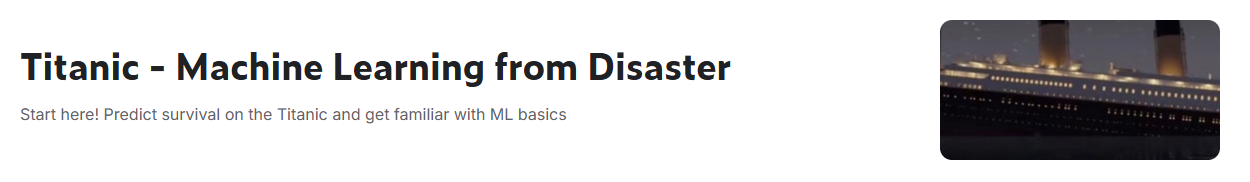

* https://www.kaggle.com/competitions/titanic/leaderboard

<pre>

survival  Survival	0 = No, 1 = Yes
pclass	  Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
sex   	  Sex	
Age	  Age in years	
sibsp	  # of siblings / spouses aboard the Titanic	
parch	  # of parents / children aboard the Titanic	
ticket	  Ticket number	
fare	  Passenger fare	
cabin	  Cabin number	
embarked  Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#----------문제/답 분리
from sklearn.model_selection import train_test_split 

#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 

#----------차원 축소
from sklearn.decomposition import PCA 

#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# **[1] Data Load**

In [3]:
train = pd.read_csv("../../Datas/#titanic/train.csv") 
test = pd.read_csv("../../Datas/#titanic/test.csv")
sub = pd.read_csv("../../Datas/#titanic/gender_submission.csv")

## **데이터 수정**

### 컬럼 소문자 변경

In [4]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

### ['passengerid'] 컬럼 삭제

In [5]:
train = train.drop(columns=['passengerid'])
test = test.drop(columns=['passengerid'])

In [6]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [7]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [8]:
sub.head(2)

,PassengerId,Survived
0,892,0
1,893,1


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    str    
 3   sex       891 non-null    str    
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    str    
 8   fare      891 non-null    float64
 9   cabin     204 non-null    str    
 10  embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [10]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    418 non-null    int64  
 1   name      418 non-null    str    
 2   sex       418 non-null    str    
 3   age       332 non-null    float64
 4   sibsp     418 non-null    int64  
 5   parch     418 non-null    int64  
 6   ticket    418 non-null    str    
 7   fare      417 non-null    float64
 8   cabin     91 non-null     str    
 9   embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 32.8 KB


* <font color='red'> 결측 있음 > 보간
* <font color='red'> 글자 있음 > 인코딩

# **[2] 1차 EDA(Exploratory Data Analysis)**

* name : 호칭 분류
* sex : male(0), female(1)
* age : 결측처리 필요
* sibsp, parch : 파생피쳐 생성(family_cnt) - 일행 total 인원수
* fare : 파생피쳐 생성(fare_rate) - 1인 요금 확인
* cabin & pclass & fare/fare_rate와의 관계 확인
* embarked : S(0), C(1), Q(2) --> 인코딩

## hist() : 데이터 분포도 확인(왜도, 첨도, 정규분포)

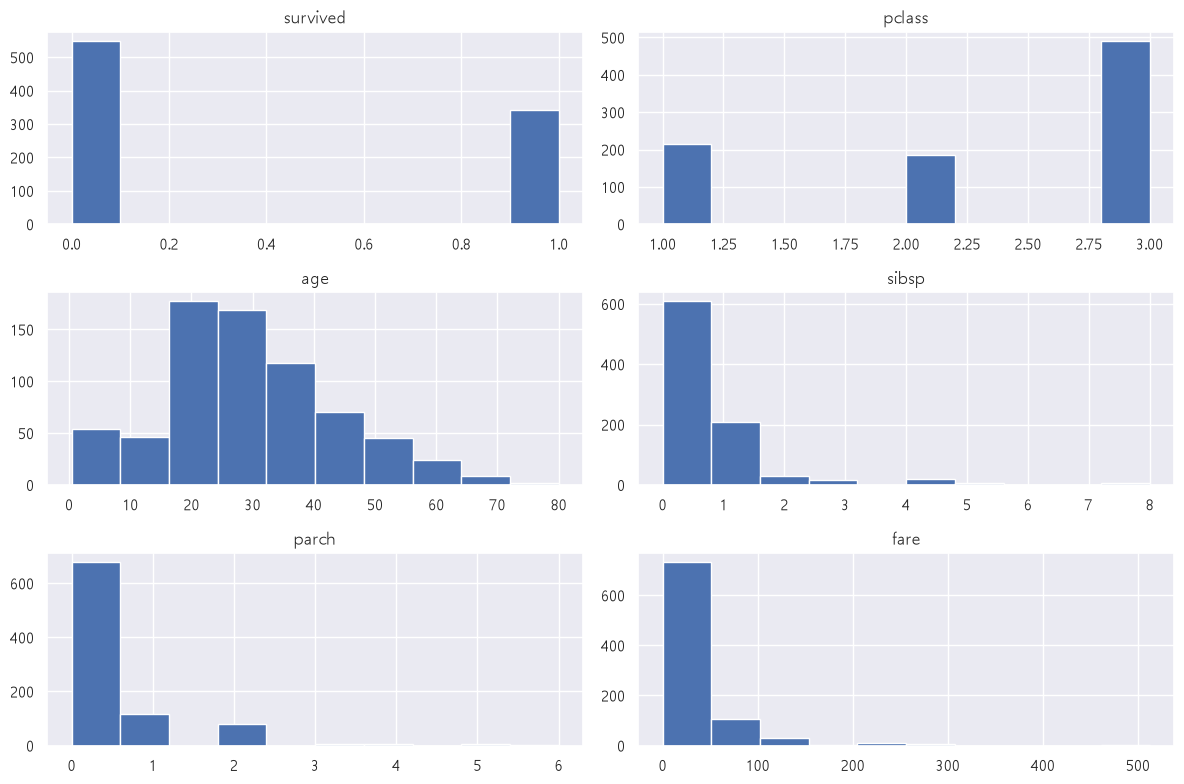

In [11]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

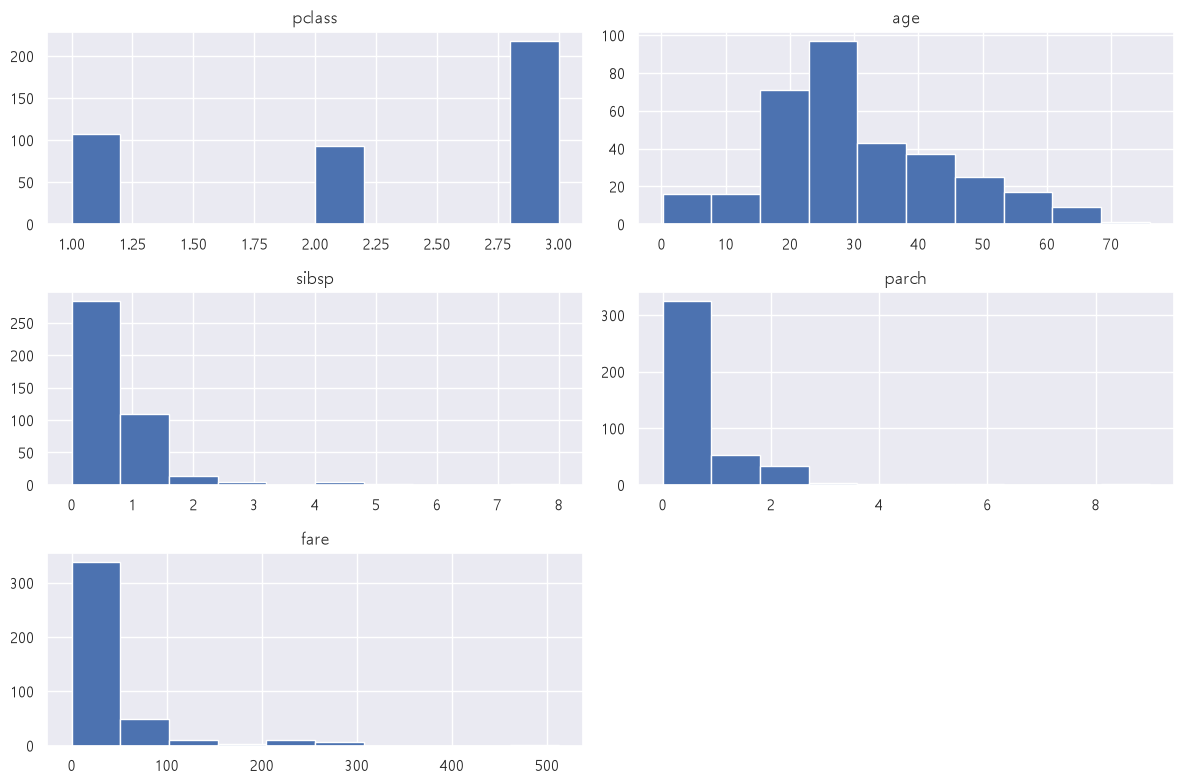

In [12]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# **[3] 전처리&가공**

* sex : male(0), female(1) --> 인코딩
* embarked : S(0) C(1) Q(2)  --> 인코딩
* 결측처리
    * age
    * embarked
* 파생피쳐
    * family_cnt = sibsp + parch + 1
    * age_group(나이대)
    * fare_rate(두당 요금)
* name : 호칭분류
* cabin : pclass , fare , fare_rate 와의 관계 -- EDA

## **(1) 인코딩 처리**
* 범주형(카테고리형) 데이터의 글자를 숫자로 변환  --- ex) 상중하, 대중소 등

### <font color=blue>**방법1) map()**

In [13]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].map({"male":0, "female":1})
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법2) replace()

In [14]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].replace(["male", "female"], [0, 1])
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법3) apply (lambda x : )

In [15]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].apply(lambda s : 0 if s == 'male' else 1)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법4) LabelEncoder()
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html#sklearn.preprocessing.LabelEncoder
* 알파벳 순서대로 0부터 인코딩 

In [16]:
le = LabelEncoder()
traincp = train.copy()
le.fit(traincp['sex'])
traincp['sex'] = le.transform(traincp['sex'])
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C


### 방법5) OneHotEncoder()
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
* <font color=red> 2D만 fit() 가능

In [17]:
oh = OneHotEncoder(sparse_output=False, dtype=int)     #--------각각 고유한 0, 1이 아닌 0 1, 1 0 이런식으로 출력  /  소수점 아니고 숫자로
oh.fit(traincp[['sex']])  
res = oh.transform(traincp[['sex']])
res

array([[0, 1],
       [1, 0],
       [1, 0],
       ...,
       [1, 0],
       [0, 1],
       [0, 1]], shape=(891, 2))

In [18]:
oh.get_feature_names_out(['sex'])    #-----원핫인코딩 후 값의 개수에 따라 컬럼을 새로 만듬

array(['sex_0', 'sex_1'], dtype=object)

In [19]:
#-------원핫인코딩 결과를 DataFrame으로 변환
temp = pd.DataFrame(res, columns=oh.get_feature_names_out(['sex']))
print(temp.shape, train.shape)
temp.head(2)

# 컬럼으로 추가하는 이유 : 알파벳순으로 소팅해서 값을 매기기 때문에 서열의 존재를 없애기 위해 (높은값을 더 중요하다고 학습하는 것을 방지하기 위해)

(891, 2) (891, 11)


,sex_0,sex_1
0,0,1
1,1,0


In [20]:
traincp = pd.concat([traincp, temp], axis=1)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex_0,sex_1
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0


### 방법6) pd.get_dummies()
* onehotencoder + get_features + concat 과 같은 문법
* dtype=int 지정 안 하면 : 기본값은 True/False로 출력됨
* <font color=red> 자동으로 원본의 동일 컬럼 drop 해줌

In [21]:
traincp = train.copy()
traincp = pd.get_dummies(traincp, columns=['sex'], dtype=int)
traincp.head(2)

,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,embarked,sex_female,sex_male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0


### <font color=blue>**원본적용**

In [22]:
train['sex'] = train['sex'].map({"male":0, "female":1})
test['sex'] = test['sex'].map({"male":0, "female":1})

In [23]:
train['embarked'] = train['embarked'].map({"S":0, "C":1, "Q":2})
test['embarked'] = test['embarked'].map({"S":0, "C":1, "Q":2})

In [24]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0


In [25]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0


## **(1-1) 호칭정리**
* ", ____. "
* r : 정규문법 기호
* \s : space
* \. : . 찾기
* (\w+) : 한글자 이상 찾기 (*공백없는 것만 가능)
* ([^\.]+) : 공백 포함 단어 찾기

In [26]:
traincp = train.copy()
testcp = test.copy()

train['name'] = traincp['name'].str.extract(r',\s([^\.]+)\.')
test['name'] = testcp['name'].str.extract(r',\s([^\.]+)\.')

train.head(2)
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,Mr,0,34.5,0,0,330911,7.8292,NaN,2
1,3,Mrs,1,47.0,1,0,363272,7.0000,NaN,0


In [27]:
train['name'].value_counts()
test['name'].value_counts()

name
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

<font color=blue> <b> ▼ 정리
* Mr : Mr, Sir, Capt, Jonkheer, Dr , Rev, Major, Col, Don  
* Mrs : Mrs, Mme, Dona
* Miss : Miss, Mlle, Ms, Lady
* Master : Master

In [28]:
mydict = { 
    'Mr': 'Mr', 'Sir': 'Mr', 'Capt': 'Mr', 'Jonkheer': 'Mr', 'Dr': 'Mr', 'Rev': 'Mr', 'Major': 'Mr', 'Col': 'Mr', 'Don': 'Mr', 'the Countess': 'Mr',
    'Mrs': 'Mrs', 'Mme': 'Mrs', 'Dona': 'Mrs', 
    'Miss': 'Miss', 'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Miss', 
    'Master': 'Master' 
        }

### <font color=blue>**원본적용**

In [29]:
#---------풀네임에서 호칭 자르기
train['name'] = traincp['name'].str.extract(r',\s([^\.]+)\.')
test['name'] = testcp['name'].str.extract(r',\s([^\.]+)\.')

#---------호칭 정리
train['name'] = train['name'].map(mydict)
test['name'] = test['name'].map(mydict)

#---------인코딩
train['name'] = train['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})
test['name'] = test['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})

In [30]:
train['name'].value_counts()

name
0    539
1    186
2    126
3     40
Name: count, dtype: int64

In [31]:
test['name'].value_counts()

name
0    245
1     79
2     73
3     21
Name: count, dtype: int64

## **(2) 결측처리**
* age, cabin, embarked

In [32]:
s = train.isna().sum()
s[s > 0]

age         177
cabin       687
embarked      2
dtype: int64

### age : 호칭별 평균 나이
* <font color=red> **transform()**

In [33]:
np.round(train.groupby("name")['age'].mean(), 1)     #--------호칭(name)별 평균값을 소수점 1자리 반올림

name
0    33.0
1    22.0
2    35.8
3     4.6
Name: age, dtype: float64

In [34]:
train['age'] = train['age'].fillna( np.round (train.groupby("name")['age'].transform('mean'), 1) )
test['age'] = test['age'].fillna( np.round (test.groupby("name")['age'].transform('mean'), 1) )

In [35]:
train.isna().sum()

survived      0
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
dtype: int64

In [36]:
test.isna().sum()

pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          1
cabin       327
embarked      0
dtype: int64

In [37]:
#fare 결측값 = 무임승차??????
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
152,3,0,0,60.5,0,0,3701,NaN,NaN,0


### embarked : 최빈도값
* S(0)로 채우기
* <font color=red> <b> mode() : Series로 값 출력 --> 정확히 값으 빼려면 mode().values[0]

In [38]:
train['embarked'].value_counts()

embarked
0.0    644
1.0    168
2.0     77
Name: count, dtype: int64

In [39]:
train['embarked'].mode()

0    0.0
Name: embarked, dtype: float64

In [40]:
train['embarked'].mode().values

array([0.])

In [41]:
print(train['embarked'].mode().values[0])

0.0


In [42]:
train['embarked'] = train['embarked'].fillna(train['embarked'].mode().values[0])

In [43]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,0,0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,2,1,38.0,1,0,PC 17599,71.2833,C85,1.0


## **(3) 불필요한 컬럼 삭제**

### ticket, cabin : 삭제

In [44]:
train['cabin'].value_counts()

cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [45]:
train[['pclass', 'cabin', 'ticket']].value_counts()

pclass  cabin        ticket  
1       C23 C25 C27  19950       4
        B96 B98      113760      4
2       F2           230080      3
1       C22 C26      113781      3
        C123         113803      2
                                ..
        A24          PC 17590    1
        B51 B53 B55  695         1
        C50          11767       1
        B42          112053      1
        C148         111369      1
Name: count, Length: 161, dtype: int64

In [46]:
train = train.drop(columns=['ticket', 'cabin'])

In [47]:
test = test.drop(columns=['ticket', 'cabin'])

In [48]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked
0,0,3,0,0,22.0,1,0,7.2500,0.0
1,1,1,2,1,38.0,1,0,71.2833,1.0


In [49]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,fare,embarked
0,3,0,0,34.5,0,0,7.8292,2
1,3,2,1,47.0,1,0,7.0000,0


## **(4) 파생피쳐 생성**

### age_group

In [50]:
train["age_group"] = train["age"]//10

### 총 가족수(family_cnt), 1인 요금(fare_rate)

In [51]:
train['family_cnt'] = train['sibsp'] + train['parch'] + 1
train['fare_rate'] = train['fare'] / train['family_cnt']

In [52]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165


In [53]:
test["age_group"] = test["age"]//10
test['family_cnt'] = test['sibsp'] + test['parch'] + 1
test['fare_rate'] = test['fare'] / test['family_cnt']

## **(2-2) 결측처리 2차**

### fare : 평균요금
* family_cnt == 1
* pclass = 3

In [54]:
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
152,3,0,0,60.5,0,0,NaN,0,6.0,1,NaN


In [55]:
train[(train['family_cnt'] == 1) & (train['pclass'] == 3)]['fare'].mean()

np.float64(9.272051851851852)

In [56]:
v = train[(train['family_cnt'] == 1) & (train['pclass'] == 3)]['fare'].mean()
test['fare'] = test['fare'].fillna(v)

In [57]:
test['fare_rate'] = test['fare'] / test['family_cnt']

# **가공처리 후 최종데이터**

In [59]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   name        891 non-null    int64  
 3   sex         891 non-null    int64  
 4   age         891 non-null    float64
 5   sibsp       891 non-null    int64  
 6   parch       891 non-null    int64  
 7   fare        891 non-null    float64
 8   embarked    891 non-null    float64
 9   age_group   891 non-null    float64
 10  family_cnt  891 non-null    int64  
 11  fare_rate   891 non-null    float64
dtypes: float64(5), int64(7)
memory usage: 83.7 KB


In [60]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      418 non-null    int64  
 1   name        418 non-null    int64  
 2   sex         418 non-null    int64  
 3   age         418 non-null    float64
 4   sibsp       418 non-null    int64  
 5   parch       418 non-null    int64  
 6   fare        418 non-null    float64
 7   embarked    418 non-null    int64  
 8   age_group   418 non-null    float64
 9   family_cnt  418 non-null    int64  
 10  fare_rate   418 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 36.1 KB


In [61]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165


# **[4] 2차 EDA(Exploratory Data Analysis)**

## **(1) 상관분석 > 인코딩 처리 후**
* <font color=red> str 피쳐는 상관분석 불가 > 인코딩 처리 후 분석

In [ ]:
# plt.figure(figsize=(10, 4))

# # 반쪽으로 보기
# mask = np.triu(np.ones_like(train.corr(), dtype=bool))
# sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
# plt.show()
# # test에는 타겟피쳐가 없기 때문에 train만 봐도 됨

In [ ]:
dddd

* atemp & temp : 0.98  --> 바이크 대여 수에 영향 큼
* count & registered : 0.97 (casual + registered = count 당연한 결과)
* workingday & week : -0.7
* mm & season : 0.97
* <font color="blue"> mm, week : 파생피쳐(연월일시 분리) 추가 생성으로 다중공선이 됨 : 필요시 파생피쳐는 삭제

## **(2) survived**

In [ ]:
plt.figure(figsize=(12,8))


plt.subplot(3, 2, 1)
sns.countplot(x="embarked", hue="survived", data=train)

plt.subplot(3, 2, 2) 
sns.countplot(x="pclass", hue="survived", data=train)

plt.subplot(3, 2, 3) 
sns.countplot(x="sex", hue="survived", data=train)

plt.subplot(3, 2, 4) 
sns.countplot(x="sibsp", hue="survived", data=train)

plt.subplot(3, 2, 5) 
sns.countplot(x="parch", hue="survived", data=train)

plt.subplot(3, 2, 6) 
#train["age_group"] = train["age"]//10
sns.countplot(x="age_group", hue="survived", data=train)


plt.tight_layout()
plt.show()

<font color=blue> <b> ▼ 분석
* S에서 탄 사람, 3등급, 남자, 가족들 없이 탄 사람, 20-30대가 죽을 확률이 큼

In [ ]:
#for문 사용
fig, axes = plt.subplots(2,3,     figsize=(14, 6)) 
col_list=[ 'embarked', 'pclass', 'sex', 'sibsp', 'parch', 'age_group']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.countplot(x=col, hue="survived", data=train,  ax=axes[줄][칸])

plt.tight_layout()
plt.show()

## **(3) 이상치(outlier) 확인**

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(14,6))
col_list = ['age', 'sibsp', 'parch', 'fare']

for i, col in enumerate(col_list) :
    줄 = i//2 
    칸 = i%2 
    sns.boxplot(x=col, data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

<font color=blue> <b> ▼ 분석
* sibsp 8, fare 500 확인 필요

# **[5] 공통함수**

### RMSLE
* <font color=red> <b> 정확도가 중요한 데이터에 사용 </font> </b>
  * ex) 실제 10 > 예측 20 : 2배   /  실제 1000 > 예측 1010 : 1.01배  ==> MSLE에서는 첫번째 오차를 훨씬 심각하게 봄 <br>
* MSE: 실제값과 예측값의 차이를 그대로 제곱해 평가하는 지표
* RMSLE: 실제값과 예측값에 로그를 적용해 비율 차이를 중심으로 평가하는 지표

$RMSLE=\sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$ <br>
* mse에 log를 적용하는 이유 : 너무 큰 데이터의 영향을 줄이고, 큰 값과 작은 값의 차이를 상대적으로 다루기 위해서 <br>
* +1을 하는 이유 : 값이 0일 때도 log를 계산할 수 있도록

``` python
sklearn.metrics.root_mean_squared_log_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

▼ train/test 데이터 비율로 나눠진 경우
* 모델 지정 안 하면 기본 랜덤포레스트, 그게 아니면 모델 이름도 같이 출력

In [ ]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )

▼ train 데이터 통으로 넣을 경우
* 모델 지정 안 하면 기본 랜덤포레스트, 그게 아니면 모델 이름도 같이 출력
* 타겟 지정 안 하면 기본 count, 지정(입력)하면 그걸로

In [ ]:
def myscore222(df, model=None, MY_TARGET="count") :
    X = df.drop(columns=['count','registered','casual'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, shuffle=False)
    
    if model is None : 
            model = RandomForestRegressor(
                n_estimators=100,
                random_state=1234
            )
    print(model.__class__.__name__) 
    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)
    
    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )

    return model

In [ ]:
rf = myscore222(train)

## <font color=blue> **→1차 점수 : 우선 점수만**
* 0.47781 : 1207등

In [ ]:
pred = rf.predict(test)
pred[:10]

In [ ]:
sub['count'] = pred
sub.head()

In [ ]:
sub.to_csv("lec11_v01.csv", index=False)
#파일로 만들기

# **[4] 전처리&가공**

## (1) 이상치 처리 : windspeed가 0인 데이터 수정

* **[1] train_target = train에 target만 꺼내놓기**
* **[1] train + test = tt 생성**

In [ ]:
print(train.shape, test.shape)

train_target = train[['count','registered','casual']]
#나중에 다시 합쳐야 하니 target으로 꺼내두기

tt = pd.concat([train, test],axis=0)
print(tt.shape)
tt.head()

* **[2] train = windspeed != 0 / test = windspeed == 0**
* 풍속이 0이 아닌 것으로 학습 후 유사패턴으로 풍속이 0인 데이터 채우기 위함

In [ ]:
tt[tt['windspeed']==0].shape,  tt[tt['windspeed']!=0].shape

In [ ]:
tt = tt.drop(columns=['count','registered','casual'])
#test에는 세가지 열이 없기 때문에 컬럼 삭제

#windspeed 기준으로 train/test, X/y 구분 ↓

tt_train = tt[tt['windspeed']!=0]    #---- 학습할 것
tt_test = tt[tt['windspeed']==0]     #---- 예측할 것


tt_train_X = tt_train.drop(columns=['windspeed'])    #---- 학습할 것 중에서 풍속 컬럼을 뺀 나머지
tt_train_y = tt_train['windspeed']                   #---- 학습할 것 중에서 풍속 컬럼

tt_test_X = tt_test.drop(columns=['windspeed'])      #---- 예측할 것 중에서 풍속 컬럼을 뺀 나머지
tt_test_y = tt_test['windspeed']      #----여기가 풍속이 0 : 여길 채워야함


rf = RandomForestRegressor(
    n_estimators=100,
    random_state=1234
)
rf.fit(tt_train_X, tt_train_y)
pred = rf.predict(tt_test_X)

print(pred[:10])

* <font color=red> **reshape : pred 결과 가로 → 세로로 바꾸기**

In [ ]:
re_pred = pred.reshape(-1, 1)
re_pred[:10]

* <font color=red> **pred 예측 결과 보기** 

In [ ]:
print(tt[tt['windspeed'] ==0].shape)

tt.loc[ tt['windspeed'] ==0, 'windspeed' ] = re_pred

print(tt[tt['windspeed'] ==0].shape)

* <font color=red> **pred 예측 결과를 tt에 넣고, 다시 target 합치기**
* 줄 인덱스 기준으로 앞뒤 잘라서 

In [ ]:
train.shape[0], test.shape[0]

train = tt[ : train.shape[0]]
train = pd.concat([train, train_target], axis=1)
test = tt[train.shape[0] : ]

## <font color=blue> **→2차 점수 : 풍속 채운 후**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등

In [ ]:
rf = myscore222(train)

In [ ]:
pred = rf.predict(test)
sub['count'] = pred
sub.head()
sub.to_csv("lec11_v02.csv", index=False)

## (2) 정규화_스케일링

* 풍속이 채워진 상태
* <font color=red> <b> train7 : test3 나눴으면 fit()은 한번만, transform()은 양쪽에

* <font color=red> <b> 시계열은 셔플 XXX 

In [ ]:
X = train.drop(columns=['count','registered','casual'])
y = train['count']
X_train7, X_val3, y_train7, y_val3 = train_test_split(X, y, test_size=0.3, shuffle=False)

### 원본 점수 : 선형모델/트리모델

In [ ]:
myscore(X_train7, y_train7, X_val3, y_val3)

lasso = Lasso()
myscore(X_train7, y_train7, X_val3, y_val3, lasso)

ridge = Ridge()
myscore(X_train7, y_train7, X_val3, y_val3, ridge)

### 스케일링 점수 : 선형모델/트리모델

In [ ]:
#모델 비교하면서 점수 확인
#ss = StandardScaler()
#ss = MinMaxScaler()
ss = RobustScaler()

ss.fit(X_train7)
X_train7_scale = ss.transform(X_train7)
X_val3_scale = ss.transform(X_val3)

#모델 지정 안 한 거 (랜덤포레스트)
myscore(X_train7, y_train7, X_val3, y_val3)

#---- 모델 지정하기 ↓
lasso = Lasso()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, lasso)       #X값 스케일한 걸로 넣음

ridge = Ridge()
myscore(X_train7_scale, y_train7, X_val3_scale, y_val3, ridge)

### 학습 후 피쳐별 중요도 확인

* <b> 트리모델 : feature_importances_

In [ ]:
rf = myscore222(train)
imp = rf.feature_importances_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

* <b> 선형모델 : model.coef_ (회귀계수==기울기==가중치==중요도)

In [ ]:
ridge = Ridge()
model = myscore222(train, ridge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

In [ ]:
lasso = Lasso()
model = myscore222(train, lasso)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

<br> <font color=blue> **▼ 분석**
* Ridge/Lasso 모델은 선형모델 : 데이터에서 yy가 가장 수치가 크니 가장 중요하다고 보여줌 (X가 크면 y가 크다고 학습)
  * 다른 컬럼 > 100이하, yy만 2000이 넘어가서
* rmsle 점수도 낮음
* 트리모델 사용이 더 나을 수 있다

### 피쳐 수정 & 삭제

* 2011-11로, 2012-12로

In [ ]:
train['yy'].value_counts()

In [ ]:
#train['yy'] = train['yy'].apply(lambda x: 1 if x == 2011 else 2)-----참고

train['yy'] = train['yy'].map({ 2011:1, 2012:2 })
test['yy'] = test['yy'].map({ 2011:1, 2012:2 })

In [ ]:
lasso = Lasso()
model = myscore222(train, lasso)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))
plt.bar(X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

* yy삭제

In [ ]:
traincp = train.copy()
traincp = traincp.drop(columns=['yy'])
traincp.head(1)

In [ ]:
traincp.columns

In [ ]:
ridge = Ridge()
model = myscore222(traincp, ridge)
imp = model.coef_
print(imp)
print(X_train7.columns)

plt.figure(figsize=(15,3))

col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp','humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp, label="블루")
plt.tight_layout
plt.show()

### <font color=red> <b> => 우리 데이터에서 Lasso/Ridge 같은 선형모델은 적합하지 않다

## (3) 정규화_규제 : 모델교체

* <b> lec05 참조 (Boston House Price)
* 우리 데이터(트리모델)에는 적합하지 않음 (규제는 선형모델에서 효과적)

# **[5] 강력한 모델로 교체**
* 선형 보다는 트리모델이 좋은 성능을 보임
* pip install xgboost, lightgbm : *GradientBoosting

## **XGBoost**
* XGBoost(Extreme Gradient Boosting)는 정형(표 형태) 데이터 예측에서 뛰어난 성능과 빠른 속도를 보여주는 그레이디언트 부스팅(Gradient Boosting) 기반의 오픈소스 머신러닝 라이브러리
* https://xgboost.ai/about

In [ ]:
# import xgboost as xgb
# model = xgb.XGBRegressor()

from xgboost import XGBRegressor, XGBClassifier    #----Regressor 회귀 / Classifier 분류
xgb = XGBRegressor()


model = myscore222(train, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar( X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

In [ ]:
xgb = XGBRegressor()
model = myscore222(traincp, xgb)
imp = model.feature_importances_

# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp','humidity', 'windspeed', 'mm', 'hh', 'week', 'day_type']
plt.bar( col_list, imp, label="블루")
plt.tight_layout
plt.show()

## **LightGBM**
* LightGBM(Light Gradient Boosting Machine)은 마이크로소프트에서 개발한 빠르고 효율적인 트리 기반의 오픈소스 머신러닝 라이브러리

In [ ]:
from lightgbm import LGBMRegressor, LGBMClassifier
model = LGBMRegressor()

In [ ]:
lgb = LGBMRegressor()

model = myscore222(train, lgb)
imp = model.feature_importances_

# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar( X_train7.columns, imp, label="블루")
plt.tight_layout
plt.show()

## <font color=blue> **→3차 점수 : 풍속 채우기 + 모델 교체**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등   ---- 오버피팅(과적합) : 해당 데이터만 과도하게 학습, 모르는 문제를 못 품 (데이터에 비해 무거운 모델 사용해서)

In [ ]:
model = myscore222(train, lgb)

In [ ]:
pred = model.predict(test)

pred = model.predict(test)
pred = np.maximum(pred, 0)

sub['count'] = pred
sub.head()
sub.to_csv("lec11_v03.csv", index=False)

In [ ]:
lgb = LGBMRegressor()
model = myscore222(train, lgb)

pred = model.predict(test)
pred = np.maximum(pred, 0)

sub['count'] = pred
sub.head()
sub.to_csv("lec11_v04.csv", index=False)

# **[6] casual / registered 타겟 분리**
* 각각 예측한 후에 합산(=count)

In [ ]:
train.columns

In [ ]:
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=1234)

model = myscore222(train, rf, MY_TARGET="casual")
pred_c = model.predict(test)
pred_c = np.maximum(pred_c, 0)

print(pred_c[:10])

In [ ]:
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=1234)

model = myscore222(train, model=None, MY_TARGET="registered")
pred_r = model.predict(test)
pred_r = np.maximum(pred_r, 0)

print(pred_c[:10])

In [ ]:
0.5499 / (0.5499+0.3528)

## <font color=blue> **→4차 점수 : casual + registered**
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등
* 4차_0.43887 : 741등! 

In [ ]:
count = pred_c + pred_r
print(count)

In [ ]:
count = np.maximum(count, 0)
sub['count'] = count
sub.head()
sub.to_csv("lec11_v04.csv", index=False)

## <font color=blue> **→5차 점수 : casual(40%) + registered(60%)**
* 잘 맞추는 모델 기준 비율 분배
* 1차_0.47781 : 1207등
* 2차_0.47739 : 1203등
* 3차_0.52408 : 1902등
* 4차_0.43887 : 741등!    ---- 22%
* 5차_0.65856 : 2409등

In [ ]:
count = (pred_c * 0.4) + (pred_r * 0.6)
print(count)

In [ ]:
count = np.maximum(count, 0)
sub['count'] = count
sub.head()
sub.to_csv("lec11_v05.csv", index=False)